# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [1]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [2]:
# TODO 1.1 — Define directory paths and create them on disk
BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR / "data" /"raw"
PROCESSED_DIR = BASE_DIR / "data" /"processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : c:\Users\sajal\OneDrive\Desktop\SOC\SOC-Stock-Trading-With-LSTM-And-RL\Week2\data\raw
PROCESSED_DIR: c:\Users\sajal\OneDrive\Desktop\SOC\SOC-Stock-Trading-With-LSTM-And-RL\Week2\data\processed


In [3]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE =     '2015-01-01'
END_DATE   =      None

#Load the market symbols in the readme as dictionary here
MARKET_SYMBOLS = {
    'india':  ["^NSEI", "^BSESN", "RELIANCE.NS", "TCS.NS", "INFY.NS"],
    'us':     ["^GSPC", "^IXIC", "SPY", "AAPL", "MSFT", "NVDA", "TSLA"],
    'crypto': ["BTC-USD", "ETH-USD"],
    'forex':  ["EURUSD=X", "JPY=X"],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [4]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'

def safe_symbol(symbol: str) -> str:
    return symbol.replace('^','').replace('.','_').replace('-','_').replace('=','_')

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [5]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function
    data = yf.download(symbol, start =start, end=end , auto_adjust=False, progress=False)

    # 2. Raise ValueError for check
    if data.empty:
        raise ValueError(f"No data found for this {symbol}")

    # 3. Flatten MultiIndex
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # 4. Reset index
    data.reset_index(inplace=True)

    # 5. Normalise column names
    data.columns=data.columns.str.lower()
    data.columns=data.columns.str.replace(' ','_')

    # 6. Add symbol column
    data["symbol"]=symbol

    return data

# Quick test
test_df = download_symbol('SPY')
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()

(2901, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


Price,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,169.687881,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,166.623337,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.053925,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.110657,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.076065,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [6]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.
for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
            df = download_symbol(symbol)
            filename=safe_symbol(symbol) + ".csv"
            df.to_csv(RAW_DIR/f"{filename}",index=False)
            print(f"{symbol} Saved")
        except Exception as e:
            print(f"Error found {e}")

^NSEI Saved
^BSESN Saved
RELIANCE.NS Saved
TCS.NS Saved
INFY.NS Saved
^GSPC Saved
^IXIC Saved
SPY Saved
AAPL Saved
MSFT Saved
NVDA Saved
TSLA Saved
BTC-USD Saved
ETH-USD Saved
EURUSD=X Saved
JPY=X Saved


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [7]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.
df = pd.read_csv("data/raw/AAPL.csv")
df["date"]=pd.to_datetime(df['date'])
df.sort_values("date" ,inplace=True)


print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2901, 8)
Dtypes:
 date         datetime64[us]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol                  str
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,24.192606,27.332500,27.860001,26.837500,27.847500,212818400,AAPL
1,2015-01-05,23.511065,26.562500,27.162500,26.352501,27.072500,257142000,AAPL
2,2015-01-06,23.513273,26.565001,26.857500,26.157499,26.635000,263188400,AAPL
3,2015-01-07,23.842978,26.937500,27.049999,26.674999,26.799999,160423600,AAPL
4,2015-01-08,24.759077,27.972500,28.037500,27.174999,27.307501,237458000,AAPL


In [8]:
# TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close

close   = df['close']
print ("Mean daily return", close.pct_change().mean())
print ("Daily return standard devaition", close.pct_change().std())
print ("Annualised volatility", close.pct_change().std()*(252**0.5))
print ("Cumulative Return",(close.iloc[-1]-close.iloc[0])/close.iloc[0])
print("Date of the all-time high close",df['date'][df['close'].idxmax()])
print("Date of the all-time low close",df['date'][df['close'].idxmin()])



# print(...)

Mean daily return 0.0010269587025501842
Daily return standard devaition 0.018109205141699603
Annualised volatility 0.2874747194759361
Cumulative Return 11.21037170565848
Date of the all-time high close 2026-07-17 00:00:00
Date of the all-time low close 2016-05-12 00:00:00


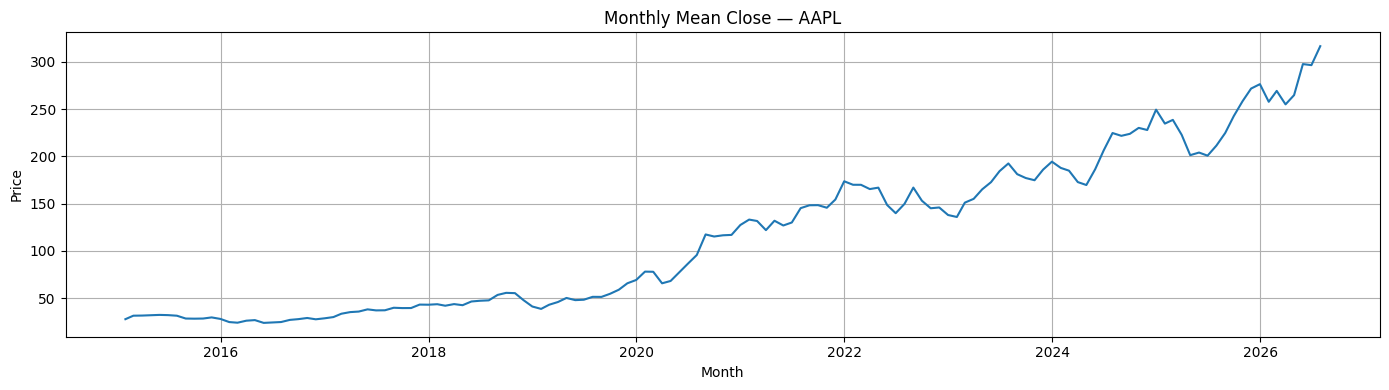

In [9]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

monthly_close = df.set_index('date')['close'].resample('ME').mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_close.index, monthly_close.values)
plt.title(f'Monthly Mean Close — AAPL')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

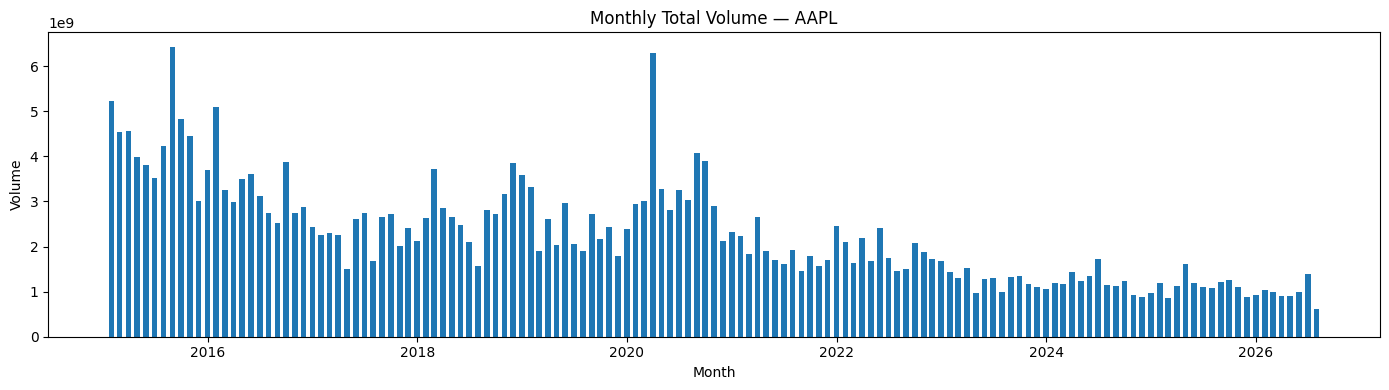

In [10]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

monthly_vol = df.set_index('date')['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
plt.bar(monthly_vol.index,monthly_vol.values,width=20)
plt.title(f'Monthly Total Volume — AAPL')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [11]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = {}
for sym in MARKET_SYMBOLS['us']:
    d =pd.read_csv(f"data/raw/{safe_symbol(sym)}.csv")
    d['date']=pd.to_datetime(d['date'])
    d.set_index('date',inplace=True)
    us_closes[f"{safe_symbol(sym)}_close"]=d["close"]

us_closes=pd.DataFrame(us_closes).ffill()
print(us_closes)

             GSPC_close    IXIC_close   SPY_close  AAPL_close  MSFT_close  \
date                                                                        
2015-01-02  2058.199951   4726.810059  205.429993   27.332500   46.759998   
2015-01-05  2020.579956   4652.569824  201.720001   26.562500   46.330002   
2015-01-06  2002.609985   4592.740234  199.820007   26.565001   45.650002   
2015-01-07  2025.900024   4650.470215  202.309998   26.937500   46.230000   
2015-01-08  2062.139893   4736.189941  205.899994   27.972500   47.590000   
...                 ...           ...         ...         ...         ...   
2026-07-13  7515.339844  25873.179688  749.169983  317.309998  390.989990   
2026-07-14  7543.589844  26107.009766  751.830017  314.859985  384.929993   
2026-07-15  7572.399902  26269.230469  754.809998  327.500000  395.630005   
2026-07-16  7533.770020  25881.949219  750.719971  333.260010  401.100006   
2026-07-17  7457.689941  25520.240234  743.289978  333.739990  393.820007   

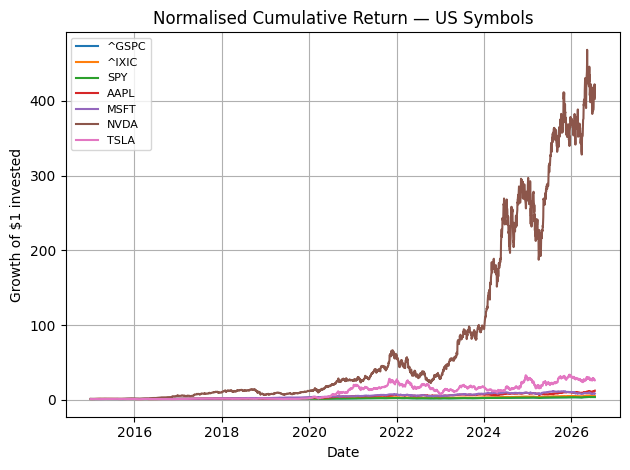

In [12]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
for sym in MARKET_SYMBOLS['us']:
    start_price=us_closes[f"{safe_symbol(sym)}_close"].iloc[0]
    us_closes[f"{safe_symbol(sym)}_close"]=us_closes[f"{safe_symbol(sym)}_close"]/start_price
    plt.plot(us_closes.index,us_closes[f"{safe_symbol(sym)}_close"], label=f"{sym}")
...
plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend()
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

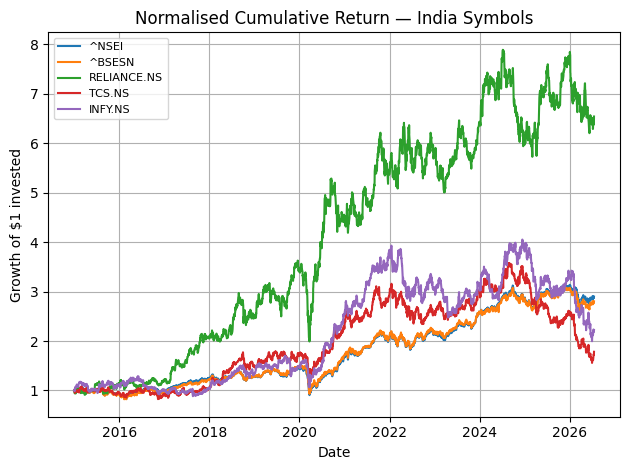

In [13]:
# TODO 5.3 — Repeat for India symbols

india_closes = {}
for sym in MARKET_SYMBOLS['india']:
    data_india=pd.read_csv(f"data/raw/{safe_symbol(sym)}.csv")
    data_india['date']=pd.to_datetime(data_india['date'])
    data_india.set_index('date',inplace=True)
    india_closes[f"{sym}"]=data_india['close']
india_closes=pd.DataFrame(india_closes).ffill().bfill()


# plot normalised series
for sym in MARKET_SYMBOLS['india']:
    base_price=india_closes[f"{sym}"].iloc[0]
    india_closes[f"{sym}"]=india_closes[f"{sym}"]/base_price
    plt.plot(india_closes.index,india_closes[f"{sym}"],label=f"{sym}")

plt.title('Normalised Cumulative Return — India Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend()
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout()
plt.show()

---
